Fitting 3 folds for each of 8 candidates, totalling 24 fits
Melhores hiperparametros: {'max_depth': 12, 'max_features': 'sqrt', 'max_samples': 0.7, 'min_samples_leaf': 8, 'min_samples_split': 11, 'n_estimators': 207}
Threshold sugerido para atraso (classe 0, F2 max): 0.3407


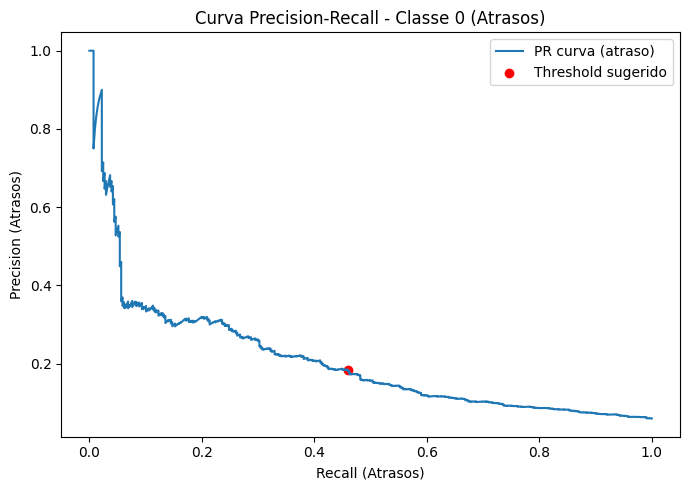


--- Metricas do Modelo (Treino x Validacao x Teste) ---
            Metrica Treino Validacao  Teste
           Accuracy 0.9478    0.9298 0.9326
Precision (Atrasos) 0.6088    0.3090 0.3621
   Recall (Atrasos) 0.3729    0.1351 0.1544
       F1 (Atrasos) 0.4625    0.1880 0.2165
       F2 (Atrasos) 0.4042    0.1523 0.1744
            ROC-AUC 0.9597    0.7221 0.7410
             PR-AUC 0.0313    0.0388 0.0376
  Balanced Accuracy 0.6787    0.5579 0.5685
                MCC 0.4512    0.1720 0.2059
        Brier Score 0.0844    0.0979 0.0968
           Log Loss 0.3301    0.3617 0.3589

--- Metricas Extras (Foco em Atrasos) ---
              Metrica Treino Validacao  Teste
     Recall (Atrasos) 0.3729    0.1351 0.1544
Specificity (Atrasos) 0.9846    0.9807 0.9825
        FNR (Atrasos) 0.6271    0.8649 0.8456
        FPR (Atrasos) 0.0154    0.0193 0.0175
        NPV (Atrasos) 0.9608    0.9466 0.9476
     PR-AUC (Atrasos) 0.6061    0.2075 0.2332

--- Relatorio de Classificacao - Treino ---
     

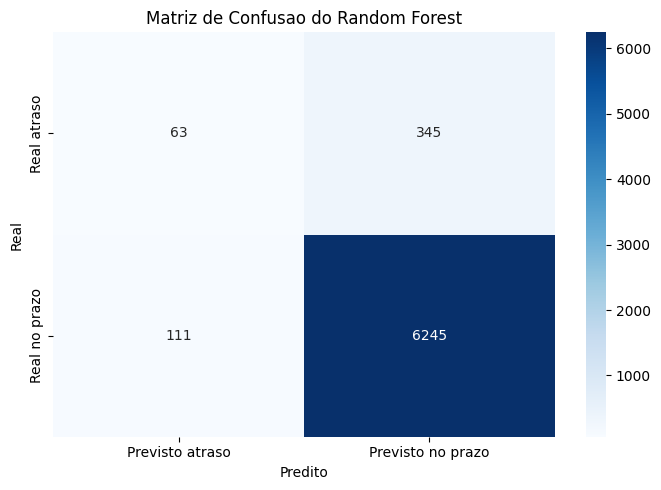

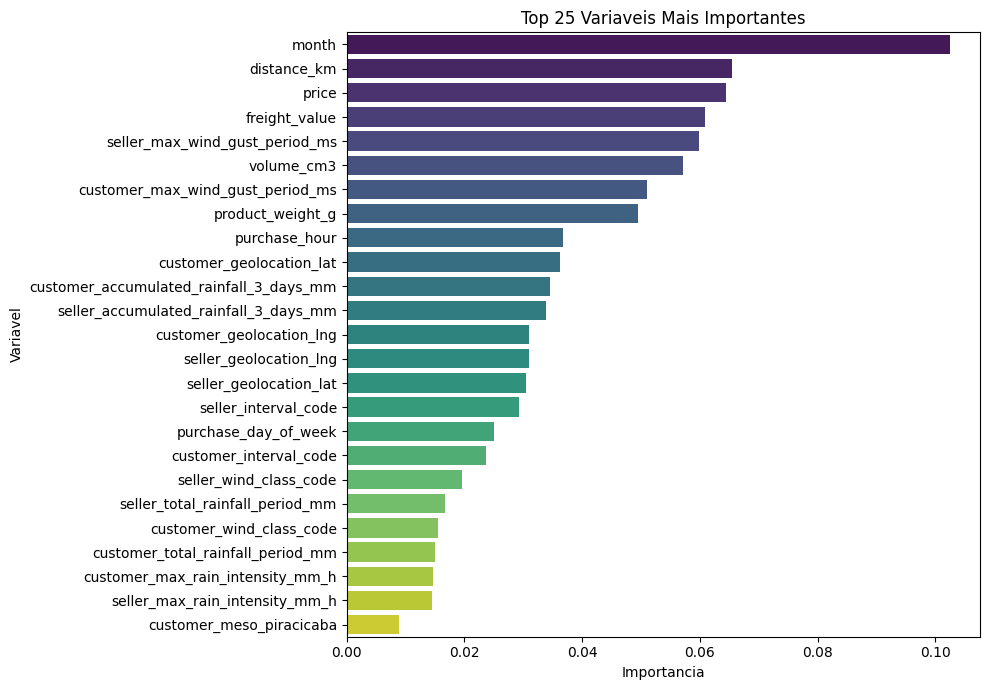

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    brier_score_loss,
    log_loss,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    auc,
    make_scorer,
 )
from scipy.stats import randint

# 1. Carregar a tabela final
csv_path = Path(r"C:\\Users\Sofhia\Downloads\ML\\tcc\\tabela_final.csv")
df = pd.read_csv(csv_path, index_col=0, delimiter=",")

# 2. Definir a variavel alvo
# 1 = entregue no prazo | 0 = entregue com atraso
y = df["delivered_on_time"]

# 3. Remover colunas com vazamento de informacao (leakage)
# Essas variaveis so existem depois que o pedido ja foi entregue ou estao diretamente ligadas ao alvo.
leakage_candidates = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "handling_time_hours",
    "shipping_delay_hours",
    "delivery_time_days",
    "review_score",
    'approval_time_hours'
]

# 4. Separar as variaveis de entrada da variavel alvo
# errors='ignore' evita falha caso alguma coluna nao exista no dataframe atual.
X = df.drop(columns=leakage_candidates + ["delivered_on_time"], errors="ignore")

# 5. Manter apenas variaveis numericas
# O Random Forest do scikit-learn precisa de valores numericos para treinar.
X = X.select_dtypes(include=[np.number])

# 6. Tratar valores ausentes
# Preenchimento simples com zero para manter o fluxo do notebook.
X = X.fillna(0)

# 7. Dividir os dados em treino, validacao e teste
# A validacao ajuda a reduzir overfit sem mexer no teste final.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y,
    shuffle=True,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp,
    shuffle=True,
)

# 8. Definir uma grade mais conservadora para reduzir overfit
param_distributions = {
    "n_estimators": randint(120, 320),
    "max_depth": randint(5, 16),
    "min_samples_split": randint(10, 30),
    "min_samples_leaf": randint(4, 14),
    "max_features": ["sqrt", "log2"],
    "max_samples": [0.6, 0.7, 0.8],
}

# 9. Criar o modelo base com class_weight alto (opcao 2)
base_model_high_weight = RandomForestClassifier(
    random_state=42,
    class_weight={0: 10, 1: 1},
    n_jobs=-1,
    bootstrap=True,
)

# 10. Buscar a melhor combinacao de hiperparametros
# A busca privilegia recall da classe de atraso.
recall_atraso_scorer = make_scorer(recall_score, pos_label=0)
search_high_weight = RandomizedSearchCV(
    estimator=base_model_high_weight,
    param_distributions=param_distributions,
    n_iter=8,
    scoring=recall_atraso_scorer,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search_high_weight.fit(X_train, y_train)

# 11. Recuperar o melhor modelo encontrado
rf_model = search_high_weight.best_estimator_
print("Melhores hiperparametros:", search_high_weight.best_params_)

# 12. Gerar predicoes de treino, validacao e teste
y_pred_train = rf_model.predict(X_train)
y_prob_train = rf_model.predict_proba(X_train)[:, 1]
y_pred_val = rf_model.predict(X_val)
y_prob_val = rf_model.predict_proba(X_val)[:, 1]
y_pred_test = rf_model.predict(X_test)
y_prob_test = rf_model.predict_proba(X_test)[:, 1]

# 12.1 Curva Precision-Recall para atrasos (classe 0) e threshold ideal
prob_atraso_val = 1 - y_prob_val
prec_0, rec_0, thr_0 = precision_recall_curve(y_val, prob_atraso_val, pos_label=0)
f2_0 = (5 * prec_0 * rec_0) / (4 * prec_0 + rec_0 + 1e-9)
best_idx = int(np.argmax(f2_0))
best_thr_atraso = thr_0[best_idx] if best_idx < len(thr_0) else 0.5
print(f"Threshold sugerido para atraso (classe 0, F2 max): {best_thr_atraso:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(rec_0, prec_0, label="PR curva (atraso)")
plt.scatter(rec_0[best_idx], prec_0[best_idx], color="red", label="Threshold sugerido")
plt.xlabel("Recall (Atrasos)")
plt.ylabel("Precision (Atrasos)")
plt.title("Curva Precision-Recall - Classe 0 (Atrasos)")
plt.legend()
plt.tight_layout()
plt.show()

# 12.2 Predicao no teste usando o threshold sugerido
prob_atraso_test = 1 - y_prob_test
y_pred_test_thr = (prob_atraso_test >= best_thr_atraso).astype(int)

# 13. Funcao para organizar metricas
# PR-AUC e calculado com average precision, que e mais estavel para classe desbalanceada.
def calcular_metricas(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Atrasos)": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Recall (Atrasos)": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "F1 (Atrasos)": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "F2 (Atrasos)": fbeta_score(y_true, y_pred, beta=2, pos_label=0, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob, pos_label=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Brier Score": brier_score_loss(y_true, y_prob),
        "Log Loss": log_loss(y_true, y_prob),
    }

def metricas_atraso_extra(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tp0 = cm[0, 0]
    fn0 = cm[0, 1]
    fp0 = cm[1, 0]
    tn0 = cm[1, 1]
    denom_rec0 = tp0 + fn0
    denom_spec0 = tn0 + fp0
    denom_npv0 = tn0 + fn0
    denom_fpr0 = fp0 + tn0
    return {
        "Recall (Atrasos)": (tp0 / denom_rec0) if denom_rec0 else 0.0,
        "Specificity (Atrasos)": (tn0 / denom_spec0) if denom_spec0 else 0.0,
        "FNR (Atrasos)": (fn0 / denom_rec0) if denom_rec0 else 0.0,
        "FPR (Atrasos)": (fp0 / denom_fpr0) if denom_fpr0 else 0.0,
        "NPV (Atrasos)": (tn0 / denom_npv0) if denom_npv0 else 0.0,
        "PR-AUC (Atrasos)": average_precision_score(y_true, 1 - y_prob, pos_label=0),
    }

metricas_treino = calcular_metricas(y_train, y_pred_train, y_prob_train)
metricas_val = calcular_metricas(y_val, y_pred_val, y_prob_val)
metricas_teste = calcular_metricas(y_test, y_pred_test, y_prob_test)

metricas_extra_treino = metricas_atraso_extra(y_train, y_pred_train, y_prob_train)
metricas_extra_val = metricas_atraso_extra(y_val, y_pred_val, y_prob_val)
metricas_extra_teste = metricas_atraso_extra(y_test, y_pred_test, y_prob_test)

# 14. Comparar metricas de treino, validacao e teste
metrics_df = pd.DataFrame({
    "Metrica": list(metricas_treino.keys()),
    "Treino": list(metricas_treino.values()),
    "Validacao": list(metricas_val.values()),
    "Teste": list(metricas_teste.values()),
})
for col in ["Treino", "Validacao", "Teste"]:
    metrics_df[col] = metrics_df[col].map(lambda v: f"{v:.4f}")

metricas_extra_df = pd.DataFrame({
    "Metrica": list(metricas_extra_treino.keys()),
    "Treino": list(metricas_extra_treino.values()),
    "Validacao": list(metricas_extra_val.values()),
    "Teste": list(metricas_extra_teste.values()),
})
for col in ["Treino", "Validacao", "Teste"]:
    metricas_extra_df[col] = metricas_extra_df[col].map(lambda v: f"{v:.4f}")

print("\n--- Metricas do Modelo (Treino x Validacao x Teste) ---")
print(metrics_df.to_string(index=False))

print("\n--- Metricas Extras (Foco em Atrasos) ---")
print(metricas_extra_df.to_string(index=False))

print("\n--- Relatorio de Classificacao - Treino ---")
print(classification_report(y_train, y_pred_train))

print("\n--- Relatorio de Classificacao - Validacao ---")
print(classification_report(y_val, y_pred_val))

print("\n--- Relatorio de Classificacao - Teste ---")
print(classification_report(y_test, y_pred_test))

print("\n--- Relatorio de Classificacao - Teste (Threshold Sugerido) ---")
print(classification_report(y_test, y_pred_test_thr))

# 15. Plotar a matriz de confusao do teste
plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_test),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Previsto atraso', 'Previsto no prazo'],
    yticklabels=['Real atraso', 'Real no prazo'],
)
plt.title('Matriz de Confusao do Random Forest')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# 16. Plotar as 25 variaveis mais importantes
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({"Feature": X.columns, "Importance": importances})
feature_df = feature_df.sort_values(by="Importance", ascending=False).head(25)

plt.figure(figsize=(10, 7))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_df,
    hue="Feature",
    dodge=False,
    palette="viridis",
    legend=False,
)
plt.title('Top 25 Variaveis Mais Importantes')
plt.xlabel('Importancia')
plt.ylabel('Variavel')
plt.tight_layout()
plt.show()

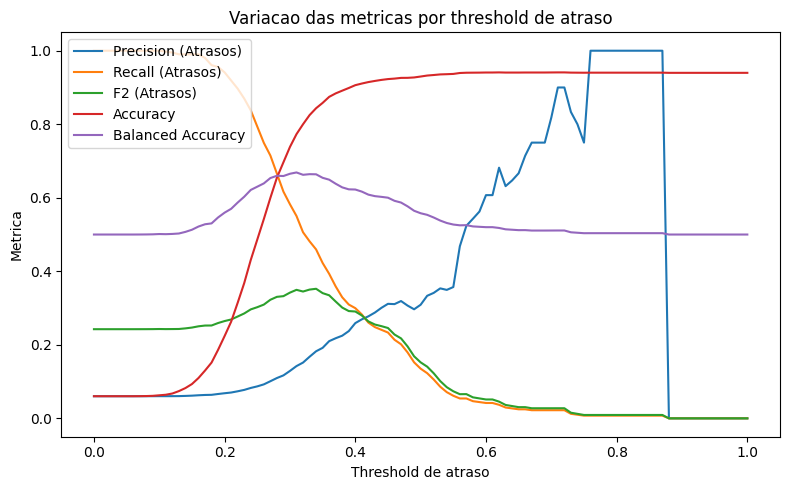

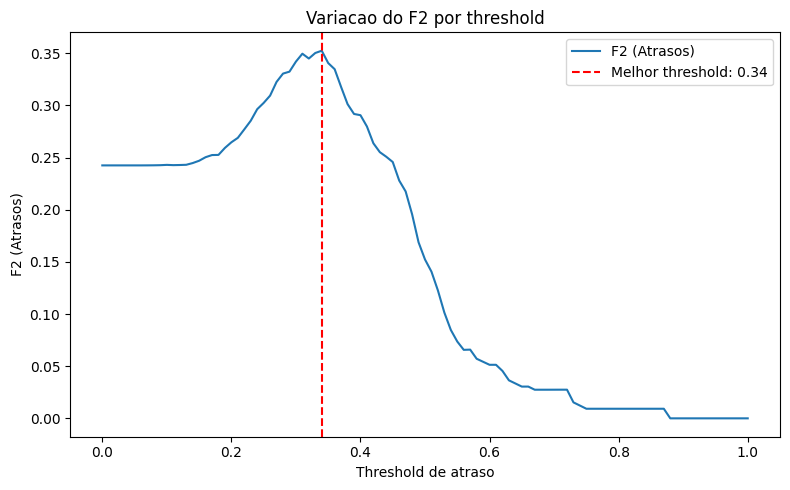

In [2]:
# Variacao das metricas por threshold de atraso (classe 0)
thresholds = np.linspace(0.0, 1.0, 101)
precisions = []
recalls = []
f2s = []
accuracies = []
balanced = []

for t in thresholds:
    y_pred_thr = np.where(prob_atraso_val >= t, 0, 1)
    accuracies.append(accuracy_score(y_val, y_pred_thr))
    precisions.append(precision_score(y_val, y_pred_thr, pos_label=0, zero_division=0))
    recalls.append(recall_score(y_val, y_pred_thr, pos_label=0, zero_division=0))
    f2s.append(fbeta_score(y_val, y_pred_thr, beta=2, pos_label=0, zero_division=0))
    balanced.append(balanced_accuracy_score(y_val, y_pred_thr))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label="Precision (Atrasos)")
plt.plot(thresholds, recalls, label="Recall (Atrasos)")
plt.plot(thresholds, f2s, label="F2 (Atrasos)")
plt.plot(thresholds, accuracies, label="Accuracy")
plt.plot(thresholds, balanced, label="Balanced Accuracy")
plt.xlabel("Threshold de atraso")
plt.ylabel("Metrica")
plt.title("Variacao das metricas por threshold de atraso")
plt.legend()
plt.tight_layout()
plt.show()

# Variacao do F2 por threshold (classe 0)
best_idx_thr = int(np.argmax(f2s))
best_thr_f2 = thresholds[best_idx_thr]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f2s, label="F2 (Atrasos)")
plt.axvline(best_thr_f2, color="red", linestyle="--", label=f"Melhor threshold: {best_thr_f2:.2f}")
plt.xlabel("Threshold de atraso")
plt.ylabel("F2 (Atrasos)")
plt.title("Variacao do F2 por threshold")
plt.legend()
plt.tight_layout()
plt.show()

Variáveis mais importantes para acertar se a entrega vai atrasar ou não

Esse modelo com class_weight alto não resolve o problema central (detectar atrasos) e o threshold sugerido piora demais o comportamento global.

Se seu objetivo é realmente capturar atrasos, você precisa voltar para uma abordagem tipo undersampling (1:3 ou 1:1) ou buscar outro modelo/feature engineering, porque o class_weight sozinho não está suficiente.

Modelo “alto peso” mantém acurácia alta (0.93), mas quase não detecta atrasos: recall de atraso no teste é só 0.115. Ou seja, ~88% dos atrasos passam batido.

Alta especificidade (0.987) confirma que ele quase nunca marca atraso quando não é, mas isso vem ao custo de ignorar atrasos reais (FNR altíssimo: 0.885).

PR-AUC baixo (0.0377) mostra que o modelo tem pouca capacidade de separar atrasos no cenário real, apesar da acurácia alta.

Threshold sugerido (0.3621) aumentou recall para 0.38, mas derrubou totalmente a acurácia e a precisão: o modelo passa a gritar “atraso” quase em massa e erra muito. Isso mostra que o ganho de recall veio com um custo inaceitável de falsos positivos.

Variacao das metricas por threshold de atraso (grafico 1): mostra o trade‑off entre capturar atrasos (recall) e evitar falsos positivos (precision). Conforme o threshold sobe, o recall tende a cair e a precision tende a subir. Accuracy e Balanced Accuracy ajudam a ver o impacto global.


Variacao do F2 por threshold (grafico 2): mostra onde oF2 (que pesa mais o recall) fica maximo. A linha vermelha marca o threshold que mais prioriza encontrar atrasos, mesmo aceitando mais falsos positivos.


Como interpretar na pratica

Threshold baixo: captura mais atrasos (recall alto), mas erra mais em pedidos no prazo (precision baixa).

Threshold alto: erra menos no prazo (precision alta), mas deixa passar atrasos (recall baixo).

O pico do F2 indica o ponto “melhor” se seu foco e nao perder atrasos.


--- Metricas Undersampling 1:1 (Treino x Validacao x Teste) ---
            Metrica Treino Validacao  Teste
           Accuracy 0.8534    0.8440 0.8468
Precision (Atrasos) 0.9556    0.1509 0.1580
   Recall (Atrasos) 0.7066    0.3440 0.3554
       F1 (Atrasos) 0.8125    0.2097 0.2187
       F2 (Atrasos) 0.7455    0.2739 0.2843
            ROC-AUC 0.9499    0.6734 0.6842
             PR-AUC 0.2740    0.0416 0.0409
  Balanced Accuracy 0.8399    0.6100 0.6169
                MCC 0.7179    0.1521 0.1625
        Brier Score 0.1444    0.1734 0.1711
           Log Loss 0.4570    0.5332 0.5280

--- Metricas Extras Undersampling 1:1 (Foco em Atrasos) ---
              Metrica Treino Validacao  Teste
     Recall (Atrasos) 0.7066    0.3440 0.3554
Specificity (Atrasos) 0.9732    0.8760 0.8784
        FNR (Atrasos) 0.2934    0.6560 0.6446
        FPR (Atrasos) 0.0268    0.1240 0.1216
        NPV (Atrasos) 0.8026    0.9542 0.9550
     PR-AUC (Atrasos) 0.9468    0.1621 0.1798

--- Relatorio de Classi

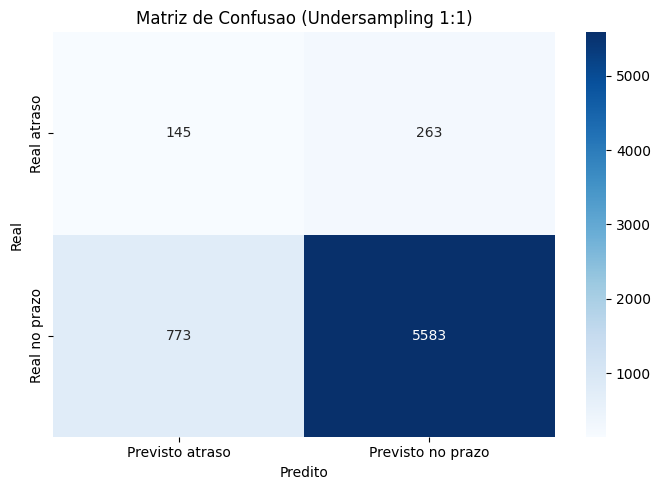

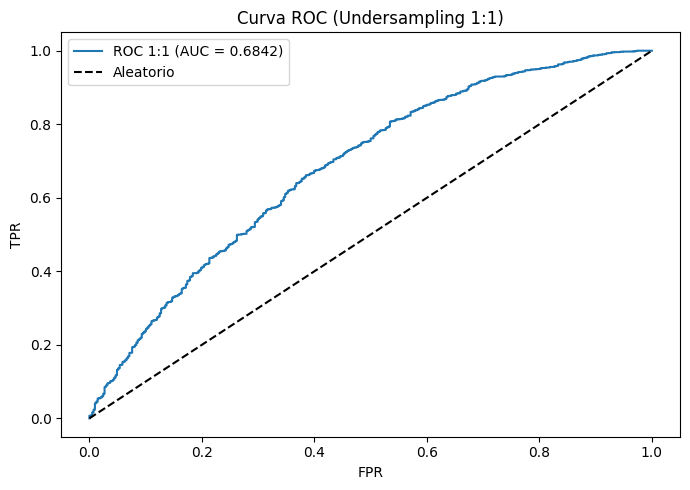

In [3]:
# Experimento: undersampling 1:1 no treino (sem class_weight)
idx_atraso_u = y_train[y_train == 0].index
idx_prazo_u = y_train[y_train == 1].index
np.random.seed(42)
idx_prazo_down_u = np.random.choice(idx_prazo_u, size=len(idx_atraso_u), replace=False)
idx_bal_u = np.concatenate([idx_atraso_u, idx_prazo_down_u])
np.random.shuffle(idx_bal_u)
X_train_u = X_train.loc[idx_bal_u]
y_train_u = y_train.loc[idx_bal_u]

rf_model_u = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    bootstrap=True,
    **search_high_weight.best_params_,
 )
rf_model_u.fit(X_train_u, y_train_u)

y_pred_train_u = rf_model_u.predict(X_train_u)
y_prob_train_u = rf_model_u.predict_proba(X_train_u)[:, 1]
y_pred_val_u = rf_model_u.predict(X_val)
y_prob_val_u = rf_model_u.predict_proba(X_val)[:, 1]
y_pred_test_u = rf_model_u.predict(X_test)
y_prob_test_u = rf_model_u.predict_proba(X_test)[:, 1]

metricas_treino_u = calcular_metricas(y_train_u, y_pred_train_u, y_prob_train_u)
metricas_val_u = calcular_metricas(y_val, y_pred_val_u, y_prob_val_u)
metricas_teste_u = calcular_metricas(y_test, y_pred_test_u, y_prob_test_u)

metricas_extra_treino_u = metricas_atraso_extra(y_train_u, y_pred_train_u, y_prob_train_u)
metricas_extra_val_u = metricas_atraso_extra(y_val, y_pred_val_u, y_prob_val_u)
metricas_extra_teste_u = metricas_atraso_extra(y_test, y_pred_test_u, y_prob_test_u)

metrics_df_u = pd.DataFrame({
    "Metrica": list(metricas_treino_u.keys()),
    "Treino": list(metricas_treino_u.values()),
    "Validacao": list(metricas_val_u.values()),
    "Teste": list(metricas_teste_u.values()),
})
for col in ["Treino", "Validacao", "Teste"]:
    metrics_df_u[col] = metrics_df_u[col].map(lambda v: f"{v:.4f}")

metricas_extra_df_u = pd.DataFrame({
    "Metrica": list(metricas_extra_treino_u.keys()),
    "Treino": list(metricas_extra_treino_u.values()),
    "Validacao": list(metricas_extra_val_u.values()),
    "Teste": list(metricas_extra_teste_u.values()),
})
for col in ["Treino", "Validacao", "Teste"]:
    metricas_extra_df_u[col] = metricas_extra_df_u[col].map(lambda v: f"{v:.4f}")

print("\n--- Metricas Undersampling 1:1 (Treino x Validacao x Teste) ---")
print(metrics_df_u.to_string(index=False))

print("\n--- Metricas Extras Undersampling 1:1 (Foco em Atrasos) ---")
print(metricas_extra_df_u.to_string(index=False))

print("\n--- Relatorio de Classificacao - Teste (Undersampling 1:1) ---")
print(classification_report(y_test, y_pred_test_u))

# Matriz de confusao (Undersampling 1:1)
plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_test_u),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Previsto atraso', 'Previsto no prazo'],
    yticklabels=['Real atraso', 'Real no prazo'],
)
plt.title('Matriz de Confusao (Undersampling 1:1)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

from sklearn.metrics import roc_curve

fpr_u, tpr_u, _ = roc_curve(y_test, y_prob_test_u)
roc_auc_u = auc(fpr_u, tpr_u)

plt.figure(figsize=(7, 5))
plt.plot(fpr_u, tpr_u, label=f"ROC 1:1 (AUC = {roc_auc_u:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Aleatorio")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC (Undersampling 1:1)")
plt.legend()
plt.tight_layout()
plt.show()


--- Metricas Undersampling 1:2 (Treino x Validacao x Teste) ---
            Metrica Treino Validacao  Teste
           Accuracy 0.8064    0.9394 0.9404
Precision (Atrasos) 0.9925    0.4694 0.5490
   Recall (Atrasos) 0.3798    0.0565 0.0686
       F1 (Atrasos) 0.5494    0.1009 0.1220
       F2 (Atrasos) 0.4333    0.0686 0.0832
            ROC-AUC 0.9474    0.7019 0.6991
             PR-AUC 0.1784    0.0395 0.0400
  Balanced Accuracy 0.6892    0.5262 0.5325
                MCC 0.5412    0.1470 0.1789
        Brier Score 0.1255    0.0994 0.0985
           Log Loss 0.4060    0.3643 0.3621

--- Metricas Extras Undersampling 1:2 (Foco em Atrasos) ---
              Metrica Treino Validacao  Teste
     Recall (Atrasos) 0.3798    0.0565 0.0686
Specificity (Atrasos) 0.9987    0.9959 0.9964
        FNR (Atrasos) 0.6202    0.9435 0.9314
        FPR (Atrasos) 0.0013    0.0041 0.0036
        NPV (Atrasos) 0.7813    0.9428 0.9434
     PR-AUC (Atrasos) 0.9104    0.1867 0.2028

--- Relatorio de Classi

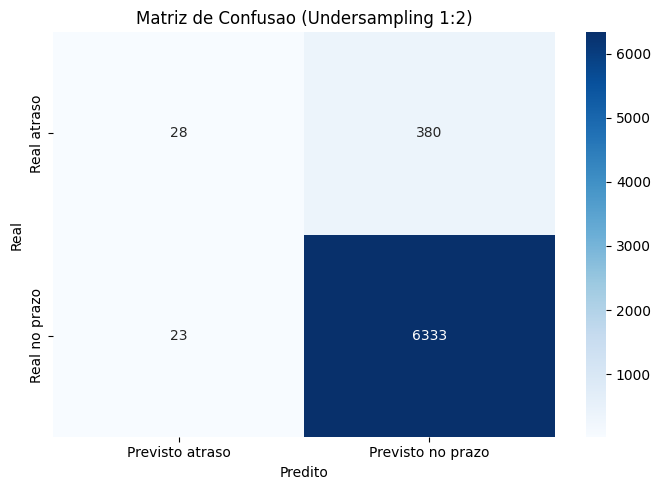

In [4]:
# Experimento: undersampling 1:2 no treino (sem class_weight)
idx_atraso_12 = y_train[y_train == 0].index
idx_prazo_12 = y_train[y_train == 1].index
np.random.seed(42)
size_major_12 = min(len(idx_prazo_12), 2 * len(idx_atraso_12))
idx_prazo_down_12 = np.random.choice(idx_prazo_12, size=size_major_12, replace=False)
idx_bal_12 = np.concatenate([idx_atraso_12, idx_prazo_down_12])
np.random.shuffle(idx_bal_12)
X_train_12 = X_train.loc[idx_bal_12]
y_train_12 = y_train.loc[idx_bal_12]

rf_model_12 = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    bootstrap=True,
    **search_high_weight.best_params_,
 )
rf_model_12.fit(X_train_12, y_train_12)

y_pred_train_12 = rf_model_12.predict(X_train_12)
y_prob_train_12 = rf_model_12.predict_proba(X_train_12)[:, 1]
y_pred_val_12 = rf_model_12.predict(X_val)
y_prob_val_12 = rf_model_12.predict_proba(X_val)[:, 1]
y_pred_test_12 = rf_model_12.predict(X_test)
y_prob_test_12 = rf_model_12.predict_proba(X_test)[:, 1]

metricas_treino_12 = calcular_metricas(y_train_12, y_pred_train_12, y_prob_train_12)
metricas_val_12 = calcular_metricas(y_val, y_pred_val_12, y_prob_val_12)
metricas_teste_12 = calcular_metricas(y_test, y_pred_test_12, y_prob_test_12)

metricas_extra_treino_12 = metricas_atraso_extra(y_train_12, y_pred_train_12, y_prob_train_12)
metricas_extra_val_12 = metricas_atraso_extra(y_val, y_pred_val_12, y_prob_val_12)
metricas_extra_teste_12 = metricas_atraso_extra(y_test, y_pred_test_12, y_prob_test_12)

metrics_df_12 = pd.DataFrame({
    "Metrica": list(metricas_treino_12.keys()),
    "Treino": list(metricas_treino_12.values()),
    "Validacao": list(metricas_val_12.values()),
    "Teste": list(metricas_teste_12.values()),
})
for col in ["Treino", "Validacao", "Teste"]:
    metrics_df_12[col] = metrics_df_12[col].map(lambda v: f"{v:.4f}")

metricas_extra_df_12 = pd.DataFrame({
    "Metrica": list(metricas_extra_treino_12.keys()),
    "Treino": list(metricas_extra_treino_12.values()),
    "Validacao": list(metricas_extra_val_12.values()),
    "Teste": list(metricas_extra_teste_12.values()),
})
for col in ["Treino", "Validacao", "Teste"]:
    metricas_extra_df_12[col] = metricas_extra_df_12[col].map(lambda v: f"{v:.4f}")

print("\n--- Metricas Undersampling 1:2 (Treino x Validacao x Teste) ---")
print(metrics_df_12.to_string(index=False))

print("\n--- Metricas Extras Undersampling 1:2 (Foco em Atrasos) ---")
print(metricas_extra_df_12.to_string(index=False))

print("\n--- Relatorio de Classificacao - Teste (Undersampling 1:2) ---")
print(classification_report(y_test, y_pred_test_12))

# Matriz de confusao (Undersampling 1:2)
plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_test_12),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Previsto atraso', 'Previsto no prazo'],
    yticklabels=['Real atraso', 'Real no prazo'],
)
plt.title('Matriz de Confusao (Undersampling 1:2)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()


--- Metricas Undersampling 1:3 (Treino x Validacao x Teste) ---
            Metrica Treino Validacao  Teste
           Accuracy 0.8292    0.9406 0.9407
Precision (Atrasos) 0.9960    0.6316 0.6667
   Recall (Atrasos) 0.2817    0.0295 0.0343
       F1 (Atrasos) 0.4392    0.0563 0.0653
       F2 (Atrasos) 0.3288    0.0364 0.0423
            ROC-AUC 0.9484    0.7021 0.7044
             PR-AUC 0.1323    0.0398 0.0397
  Balanced Accuracy 0.6407    0.5142 0.5166
                MCC 0.4783    0.1275 0.1421
        Brier Score 0.1090    0.0758 0.0750
           Log Loss 0.3596    0.2997 0.2975

--- Metricas Extras Undersampling 1:3 (Foco em Atrasos) ---
              Metrica Treino Validacao  Teste
     Recall (Atrasos) 0.2817    0.0295 0.0343
Specificity (Atrasos) 0.9996    0.9989 0.9989
        FNR (Atrasos) 0.7183    0.9705 0.9657
        FPR (Atrasos) 0.0004    0.0011 0.0011
        NPV (Atrasos) 0.8172    0.9414 0.9416
     PR-AUC (Atrasos) 0.8855    0.1954 0.2177

--- Relatorio de Classi

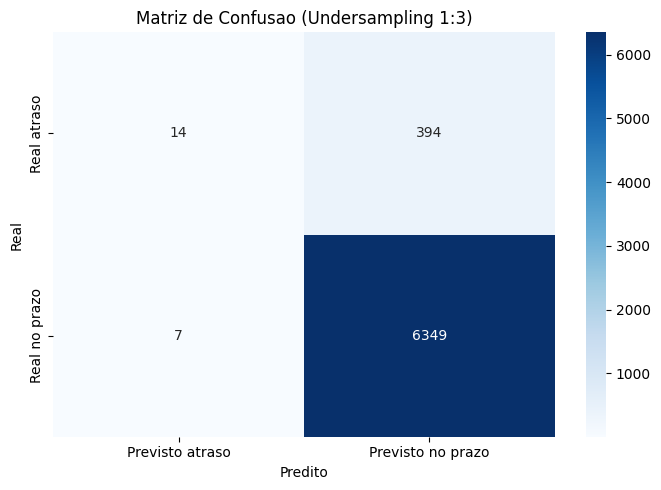

In [5]:
# Experimento: undersampling 1:3 no treino (sem class_weight)
idx_atraso_13 = y_train[y_train == 0].index
idx_prazo_13 = y_train[y_train == 1].index
np.random.seed(42)
size_major_13 = min(len(idx_prazo_13), 3 * len(idx_atraso_13))
idx_prazo_down_13 = np.random.choice(idx_prazo_13, size=size_major_13, replace=False)
idx_bal_13 = np.concatenate([idx_atraso_13, idx_prazo_down_13])
np.random.shuffle(idx_bal_13)
X_train_13 = X_train.loc[idx_bal_13]
y_train_13 = y_train.loc[idx_bal_13]

rf_model_13 = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    bootstrap=True,
    **search_high_weight.best_params_,
 )
rf_model_13.fit(X_train_13, y_train_13)

y_pred_train_13 = rf_model_13.predict(X_train_13)
y_prob_train_13 = rf_model_13.predict_proba(X_train_13)[:, 1]
y_pred_val_13 = rf_model_13.predict(X_val)
y_prob_val_13 = rf_model_13.predict_proba(X_val)[:, 1]
y_pred_test_13 = rf_model_13.predict(X_test)
y_prob_test_13 = rf_model_13.predict_proba(X_test)[:, 1]

metricas_treino_13 = calcular_metricas(y_train_13, y_pred_train_13, y_prob_train_13)
metricas_val_13 = calcular_metricas(y_val, y_pred_val_13, y_prob_val_13)
metricas_teste_13 = calcular_metricas(y_test, y_pred_test_13, y_prob_test_13)

metricas_extra_treino_13 = metricas_atraso_extra(y_train_13, y_pred_train_13, y_prob_train_13)
metricas_extra_val_13 = metricas_atraso_extra(y_val, y_pred_val_13, y_prob_val_13)
metricas_extra_teste_13 = metricas_atraso_extra(y_test, y_pred_test_13, y_prob_test_13)

metrics_df_13 = pd.DataFrame({
    "Metrica": list(metricas_treino_13.keys()),
    "Treino": list(metricas_treino_13.values()),
    "Validacao": list(metricas_val_13.values()),
    "Teste": list(metricas_teste_13.values()),
})
for col in ["Treino", "Validacao", "Teste"]:
    metrics_df_13[col] = metrics_df_13[col].map(lambda v: f"{v:.4f}")

metricas_extra_df_13 = pd.DataFrame({
    "Metrica": list(metricas_extra_treino_13.keys()),
    "Treino": list(metricas_extra_treino_13.values()),
    "Validacao": list(metricas_extra_val_13.values()),
    "Teste": list(metricas_extra_teste_13.values()),
})
for col in ["Treino", "Validacao", "Teste"]:
    metricas_extra_df_13[col] = metricas_extra_df_13[col].map(lambda v: f"{v:.4f}")

print("\n--- Metricas Undersampling 1:3 (Treino x Validacao x Teste) ---")
print(metrics_df_13.to_string(index=False))

print("\n--- Metricas Extras Undersampling 1:3 (Foco em Atrasos) ---")
print(metricas_extra_df_13.to_string(index=False))

print("\n--- Relatorio de Classificacao - Teste (Undersampling 1:3) ---")
print(classification_report(y_test, y_pred_test_13))

# Matriz de confusao (Undersampling 1:3)
plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_test_13),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Previsto atraso', 'Previsto no prazo'],
    yticklabels=['Real atraso', 'Real no prazo'],
)
plt.title('Matriz de Confusao (Undersampling 1:3)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

In [6]:
# Tabela comparativa: teste (1:1, 1:2, 1:3)
comparativo_teste = pd.DataFrame({
    "Metrica": list(metricas_teste_u.keys()),
    "1:1": list(metricas_teste_u.values()),
    "1:2": list(metricas_teste_12.values()),
    "1:3": list(metricas_teste_13.values()),
})
for col in ["1:1", "1:2", "1:3"]:
    comparativo_teste[col] = comparativo_teste[col].map(lambda v: f"{v:.4f}")

comparativo_extra = pd.DataFrame({
    "Metrica": list(metricas_extra_teste_u.keys()),
    "1:1": list(metricas_extra_teste_u.values()),
    "1:2": list(metricas_extra_teste_12.values()),
    "1:3": list(metricas_extra_teste_13.values()),
})
for col in ["1:1", "1:2", "1:3"]:
    comparativo_extra[col] = comparativo_extra[col].map(lambda v: f"{v:.4f}")

print("\n--- Comparativo (Teste) ---")
print(comparativo_teste.to_string(index=False))

print("\n--- Comparativo Extra (Teste - Foco em Atrasos) ---")
print(comparativo_extra.to_string(index=False))

display(comparativo_teste)
display(comparativo_extra)


--- Comparativo (Teste) ---
            Metrica    1:1    1:2    1:3
           Accuracy 0.8468 0.9404 0.9407
Precision (Atrasos) 0.1580 0.5490 0.6667
   Recall (Atrasos) 0.3554 0.0686 0.0343
       F1 (Atrasos) 0.2187 0.1220 0.0653
       F2 (Atrasos) 0.2843 0.0832 0.0423
            ROC-AUC 0.6842 0.6991 0.7044
             PR-AUC 0.0409 0.0400 0.0397
  Balanced Accuracy 0.6169 0.5325 0.5166
                MCC 0.1625 0.1789 0.1421
        Brier Score 0.1711 0.0985 0.0750
           Log Loss 0.5280 0.3621 0.2975

--- Comparativo Extra (Teste - Foco em Atrasos) ---
              Metrica    1:1    1:2    1:3
     Recall (Atrasos) 0.3554 0.0686 0.0343
Specificity (Atrasos) 0.8784 0.9964 0.9989
        FNR (Atrasos) 0.6446 0.9314 0.9657
        FPR (Atrasos) 0.1216 0.0036 0.0011
        NPV (Atrasos) 0.9550 0.9434 0.9416
     PR-AUC (Atrasos) 0.1798 0.2028 0.2177


,Metrica,1:1,1:2,1:3
0,Accuracy,0.8468,0.9404,0.9407
1,Precision (Atrasos),0.1580,0.5490,0.6667
2,Recall (Atrasos),0.3554,0.0686,0.0343
3,F1 (Atrasos),0.2187,0.1220,0.0653
4,F2 (Atrasos),0.2843,0.0832,0.0423
5,ROC-AUC,0.6842,0.6991,0.7044
6,PR-AUC,0.0409,0.0400,0.0397
7,Balanced Accuracy,0.6169,0.5325,0.5166
8,MCC,0.1625,0.1789,0.1421
9,Brier Score,0.1711,0.0985,0.0750


,Metrica,1:1,1:2,1:3
0,Recall (Atrasos),0.3554,0.0686,0.0343
1,Specificity (Atrasos),0.8784,0.9964,0.9989
2,FNR (Atrasos),0.6446,0.9314,0.9657
3,FPR (Atrasos),0.1216,0.0036,0.0011
4,NPV (Atrasos),0.9550,0.9434,0.9416
5,PR-AUC (Atrasos),0.1798,0.2028,0.2177


Comparando o objetivo principal (classe 0):

1:1 (search): Recall atraso 0.39, F2 0.31
1:3 (search): Recall atraso 0.04, F2 0.05
Ou seja, o 1:3 praticamente voltou ao comportamento “padrão” (quase não marca atraso), mesmo com precisão alta. Ele só ficou bom em evitar falsos positivos, mas falha no objetivo de capturar atrasos.

Se seu foco é identificar o máximo de atrasos, o 1:1 está claramente melhor.
Se o foco fosse minimizar alarmes falsos, aí o 1:3 faria mais sentido.



Se o objetivo principal é detectar atrasos (classe 0), o melhor foi 1:1. Ele teve o maior recall e F2 no teste:

1:1 → Recall atraso 0.2549, F2 0.2244
1:2 → Recall atraso 0.0441, F2 0.0541
1:3 → Recall atraso 0.0319, F2 0.0395
Por que?

O 1:1 aceita mais falsos positivos, mas captura bem mais atrasos reais, que é o seu foco.
O 1:2 e o 1:3 aumentam acuracia e precisao de atraso, mas quase nao marcam atraso (recall muito baixo), ou seja, deixam passar a maioria dos atrasos.